In [178]:
# Define the file path
file_path = '/content/Combined_Flights_2022.csv'

In [179]:
import pandas as pd

In [180]:
# Load the dataset
data = pd.read_csv(file_path, low_memory=False, on_bad_lines='skip')


In [181]:
# Display dataset structure and column details
print("Dataset Info:")
print(data.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4078318 entries, 0 to 4078317
Data columns (total 61 columns):
 #   Column                                   Dtype  
---  ------                                   -----  
 0   FlightDate                               object 
 1   Airline                                  object 
 2   Origin                                   object 
 3   Dest                                     object 
 4   Cancelled                                bool   
 5   Diverted                                 bool   
 6   CRSDepTime                               int64  
 7   DepTime                                  float64
 8   DepDelayMinutes                          float64
 9   DepDelay                                 float64
 10  ArrTime                                  float64
 11  ArrDelayMinutes                          float64
 12  AirTime                                  float64
 13  CRSElapsedTime                           float64
 14  Actu

In [182]:
!pip install pyspark

In [183]:
from pyspark.sql import SparkSession

# Initialize a Spark session
# .appName sets a name for the application, which will appear in the Spark web UI
# .getOrCreate() tries to retrieve an existing Spark session; if none exists, a new one is created
spark = SparkSession.builder \
    .appName("Flight Data Analysis") \
    .getOrCreate()


In [184]:
# Load the dataset from a CSV file
df = spark.read.option("header", "true").csv('/content/Combined_Flights_2022.csv')

In [185]:
df.show(5)

+----------+--------------------+------+----+---------+--------+----------+-------+---------------+--------+-------+---------------+-------+--------------+-----------------+--------+----+-------+-----+----------+---------+-------------------------+---------------------------------------+------------------------+---------------------------+-------------------------------+-----------------+------------------------+---------------------------+-----------+-------------------------------+---------------+------------------+------------------+--------------------+-----------+---------------+---------------+---------+-------------+----------------+----------------+-------------------+---------+-------------+-------------+-------+--------+--------------------+----------+-------+---------+--------+------+----------+--------+--------+------------------+----------+-------------+------------------+
|FlightDate|             Airline|Origin|Dest|Cancelled|Diverted|CRSDepTime|DepTime|DepDelayMinutes|De

In [186]:
df.printSchema()

root
 |-- FlightDate: string (nullable = true)
 |-- Airline: string (nullable = true)
 |-- Origin: string (nullable = true)
 |-- Dest: string (nullable = true)
 |-- Cancelled: string (nullable = true)
 |-- Diverted: string (nullable = true)
 |-- CRSDepTime: string (nullable = true)
 |-- DepTime: string (nullable = true)
 |-- DepDelayMinutes: string (nullable = true)
 |-- DepDelay: string (nullable = true)
 |-- ArrTime: string (nullable = true)
 |-- ArrDelayMinutes: string (nullable = true)
 |-- AirTime: string (nullable = true)
 |-- CRSElapsedTime: string (nullable = true)
 |-- ActualElapsedTime: string (nullable = true)
 |-- Distance: string (nullable = true)
 |-- Year: string (nullable = true)
 |-- Quarter: string (nullable = true)
 |-- Month: string (nullable = true)
 |-- DayofMonth: string (nullable = true)
 |-- DayOfWeek: string (nullable = true)
 |-- Marketing_Airline_Network: string (nullable = true)
 |-- Operated_or_Branded_Code_Share_Partners: string (nullable = true)
 |-- DOT

In [187]:
from pyspark.sql.functions import col
from pyspark.sql.types import IntegerType, BooleanType, FloatType, StringType, DateType

# Convert column data types
df = df.withColumn("FlightDate", col("FlightDate").cast(DateType())) \
       .withColumn("Cancelled", col("Cancelled").cast(BooleanType())) \
       .withColumn("Diverted", col("Diverted").cast(BooleanType())) \
       .withColumn("CRSDepTime", col("CRSDepTime").cast(IntegerType())) \
       .withColumn("DepTime", col("DepTime").cast(IntegerType())) \
       .withColumn("DepDelayMinutes", col("DepDelayMinutes").cast(IntegerType())) \
       .withColumn("DepDelay", col("DepDelay").cast(IntegerType())) \
       .withColumn("ArrTime", col("ArrTime").cast(IntegerType())) \
       .withColumn("ArrDelayMinutes", col("ArrDelayMinutes").cast(IntegerType())) \
       .withColumn("AirTime", col("AirTime").cast(IntegerType())) \
       .withColumn("CRSElapsedTime", col("CRSElapsedTime").cast(IntegerType())) \
       .withColumn("ActualElapsedTime", col("ActualElapsedTime").cast(IntegerType())) \
       .withColumn("Distance", col("Distance").cast(FloatType())) \
       .withColumn("Year", col("Year").cast(IntegerType())) \
       .withColumn("Quarter", col("Quarter").cast(IntegerType())) \
       .withColumn("Month", col("Month").cast(IntegerType())) \
       .withColumn("DayofMonth", col("DayofMonth").cast(IntegerType())) \
       .withColumn("DayOfWeek", col("DayOfWeek").cast(IntegerType())) \
       .withColumn("DOT_ID_Marketing_Airline", col("DOT_ID_Marketing_Airline").cast(IntegerType())) \
       .withColumn("DOT_ID_Operating_Airline", col("DOT_ID_Operating_Airline").cast(IntegerType())) \
       .withColumn("Flight_Number_Marketing_Airline", col("Flight_Number_Marketing_Airline").cast(IntegerType())) \
       .withColumn("Flight_Number_Operating_Airline", col("Flight_Number_Operating_Airline").cast(IntegerType())) \
       .withColumn("OriginAirportID", col("OriginAirportID").cast(IntegerType())) \
       .withColumn("DestAirportID", col("DestAirportID").cast(IntegerType())) \
       .withColumn("OriginAirportSeqID", col("OriginAirportSeqID").cast(IntegerType())) \
       .withColumn("DestAirportSeqID", col("DestAirportSeqID").cast(IntegerType())) \
       .withColumn("OriginCityMarketID", col("OriginCityMarketID").cast(IntegerType())) \
       .withColumn("DestCityMarketID", col("DestCityMarketID").cast(IntegerType())) \
       .withColumn("OriginStateFips", col("OriginStateFips").cast(IntegerType())) \
       .withColumn("DestStateFips", col("DestStateFips").cast(IntegerType())) \
       .withColumn("OriginWac", col("OriginWac").cast(IntegerType())) \
       .withColumn("DestWac", col("DestWac").cast(IntegerType())) \
       .withColumn("DepDel15", col("DepDel15").cast(BooleanType())) \
       .withColumn("ArrDel15", col("ArrDel15").cast(BooleanType())) \
       .withColumn("DepartureDelayGroups", col("DepartureDelayGroups").cast(IntegerType())) \
       .withColumn("ArrivalDelayGroups", col("ArrivalDelayGroups").cast(IntegerType())) \
       .withColumn("TaxiOut", col("TaxiOut").cast(IntegerType())) \
       .withColumn("WheelsOff", col("WheelsOff").cast(IntegerType())) \
       .withColumn("WheelsOn", col("WheelsOn").cast(IntegerType())) \
       .withColumn("TaxiIn", col("TaxiIn").cast(IntegerType())) \
       .withColumn("ArrDelay", col("ArrDelay").cast(IntegerType())) \
       .withColumn("DivAirportLandings", col("DivAirportLandings").cast(IntegerType()))

In [188]:
# Show updated schema to confirm changes
df.printSchema()

root
 |-- FlightDate: date (nullable = true)
 |-- Airline: string (nullable = true)
 |-- Origin: string (nullable = true)
 |-- Dest: string (nullable = true)
 |-- Cancelled: boolean (nullable = true)
 |-- Diverted: boolean (nullable = true)
 |-- CRSDepTime: integer (nullable = true)
 |-- DepTime: integer (nullable = true)
 |-- DepDelayMinutes: integer (nullable = true)
 |-- DepDelay: integer (nullable = true)
 |-- ArrTime: integer (nullable = true)
 |-- ArrDelayMinutes: integer (nullable = true)
 |-- AirTime: integer (nullable = true)
 |-- CRSElapsedTime: integer (nullable = true)
 |-- ActualElapsedTime: integer (nullable = true)
 |-- Distance: float (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Quarter: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- DayofMonth: integer (nullable = true)
 |-- DayOfWeek: integer (nullable = true)
 |-- Marketing_Airline_Network: string (nullable = true)
 |-- Operated_or_Branded_Code_Share_Partners: string (nullable = t

In [189]:
from pyspark.sql.functions import count, when

# Calculate the number of missing values per column using DataFrame operations
missing_data = df.select([count(when(col(c).isNull() | (col(c) == ''), c)).alias(c) for c in df.columns])

# Display the number of missing values per column
missing_data.show(truncate=False)

+----------+-------+------+----+---------+--------+----------+-------+---------------+--------+-------+---------------+-------+--------------+-----------------+--------+----+-------+-----+----------+---------+-------------------------+---------------------------------------+------------------------+---------------------------+-------------------------------+-----------------+------------------------+---------------------------+-----------+-------------------------------+---------------+------------------+------------------+--------------+-----------+---------------+---------------+---------+-------------+----------------+----------------+------------+---------+-------------+-------------+-------+--------+--------------------+----------+-------+---------+--------+------+----------+--------+--------+------------------+----------+-------------+------------------+
|FlightDate|Airline|Origin|Dest|Cancelled|Diverted|CRSDepTime|DepTime|DepDelayMinutes|DepDelay|ArrTime|ArrDelayMinutes|AirTime|

In [190]:

# List of columns related to time and delays
time_delay_columns = ['DepTime', 'ArrTime', 'DepDelayMinutes', 'ArrDelayMinutes', 'DepDelay', 'ArrDelay']

# Fill missing values in these columns with 0
for column in time_delay_columns:
    df = df.withColumn(column, col(column).cast("integer"))  # Ensure the column is integer type
    df = df.na.fill({column: 0})

In [191]:
# Ensure that critical identifiers are not null
critical_columns = ['FlightDate', 'Airline', 'Origin', 'Dest', 'OriginAirportID', 'DestAirportID']
df = df.na.drop(subset=critical_columns)  # Drop rows where any critical column is null

In [192]:
# Fill missing values in ActualElapsedTime with 0
df = df.na.fill({"ActualElapsedTime": 0})

In [193]:
# Fill missing Tail Numbers with 'Unknown'
df = df.na.fill({'Tail_Number': 'Unknown'})

In [194]:
# Show the updated schema and some rows to verify changes
df.printSchema()
df.show(truncate=False)

root
 |-- FlightDate: date (nullable = true)
 |-- Airline: string (nullable = true)
 |-- Origin: string (nullable = true)
 |-- Dest: string (nullable = true)
 |-- Cancelled: boolean (nullable = true)
 |-- Diverted: boolean (nullable = true)
 |-- CRSDepTime: integer (nullable = true)
 |-- DepTime: integer (nullable = false)
 |-- DepDelayMinutes: integer (nullable = false)
 |-- DepDelay: integer (nullable = false)
 |-- ArrTime: integer (nullable = false)
 |-- ArrDelayMinutes: integer (nullable = false)
 |-- AirTime: integer (nullable = true)
 |-- CRSElapsedTime: integer (nullable = true)
 |-- ActualElapsedTime: integer (nullable = false)
 |-- Distance: float (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Quarter: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- DayofMonth: integer (nullable = true)
 |-- DayOfWeek: integer (nullable = true)
 |-- Marketing_Airline_Network: string (nullable = true)
 |-- Operated_or_Branded_Code_Share_Partners: string (nullab

In [195]:
# Fill missing values in AirTime with 0
df = df.na.fill({"AirTime": 0})

In [196]:
# Calculate DepDel15 based on DepDelayMinutes being 15 or more minutes
df = df.withColumn("DepDel15", when(col("DepDelayMinutes") >= 15, True).otherwise(False))

In [197]:
from pyspark.sql.functions import floor

# Assume DepDelayMinutes is already an integer column; if not, cast it first
df = df.withColumn("DepDelayMinutes", col("DepDelayMinutes").cast("integer"))

# Define DepartureDelayGroups based on DepDelayMinutes
# Grouping: -1 for early, 0 for on time (less than 15 minutes delay), 1 for 15-29 minutes delay, etc.
df = df.withColumn("DepartureDelayGroups",
                   when(col("DepDelayMinutes") < 0, -1)  # Early departure
                   .when(col("DepDelayMinutes") < 15, 0)  # On-time
                   .otherwise(floor((col("DepDelayMinutes") - 15) / 15) + 1))  # Delay groups

In [198]:
# List of columns where missing values will lead to row being dropped
columns_to_check = ["TaxiOut", "WheelsOff", "WheelsOn", "TaxiIn"]

# Drop rows that have null values in any of the specified columns
df = df.dropna(subset=columns_to_check)

In [199]:
df = df.withColumn("ArrDel15", when(col("ArrDelayMinutes") >= 15, True).otherwise(False))

In [200]:
df = df.withColumn("ArrivalDelayGroups", floor((col("ArrDelayMinutes") + 1) / 15))

In [201]:
# Calculate the number of missing values per column using DataFrame operations
missing_data = df.select([count(when(col(c).isNull() | (col(c) == ''), c)).alias(c) for c in df.columns])

# Display the number of missing values per column
missing_data.show(truncate=False)

+----------+-------+------+----+---------+--------+----------+-------+---------------+--------+-------+---------------+-------+--------------+-----------------+--------+----+-------+-----+----------+---------+-------------------------+---------------------------------------+------------------------+---------------------------+-------------------------------+-----------------+------------------------+---------------------------+-----------+-------------------------------+---------------+------------------+------------------+--------------+-----------+---------------+---------------+---------+-------------+----------------+----------------+------------+---------+-------------+-------------+-------+--------+--------------------+----------+-------+---------+--------+------+----------+--------+--------+------------------+----------+-------------+------------------+
|FlightDate|Airline|Origin|Dest|Cancelled|Diverted|CRSDepTime|DepTime|DepDelayMinutes|DepDelay|ArrTime|ArrDelayMinutes|AirTime|

In [202]:
# Show a summary of the dataset to check the changes
df.describe().show()

# Check the first few rows to ensure the data looks correct
df.show(5)

+-------+--------------------+-------+-------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+-----------------+--------------------+------------------+------------------+------------------+-----------------+-------------------------+---------------------------------------+------------------------+---------------------------+-------------------------------+-----------------+------------------------+---------------------------+-----------+-------------------------------+------------------+------------------+------------------+--------------+-----------+-----------------+---------------+------------------+------------------+------------------+------------------+------------+---------+------------------+-------------+-----------------+--------------------+----------+------------------+------------------+------------------+-----------------+------------------+----------

In [203]:
# Register the DataFrame as a temporary SQL table
df.createOrReplaceTempView("flights")

In [204]:
# Query 1: Top 10 Airlines with the Most Departure Delays
query1 = """
SELECT Marketing_Airline_Network AS Airline, COUNT(*) AS DelayCount
FROM flights
WHERE DepDelayMinutes > 0
GROUP BY Marketing_Airline_Network
ORDER BY DelayCount DESC
LIMIT 10
"""
result1 = spark.sql(query1)
result1.show()

+-------+----------+
|Airline|DelayCount|
+-------+----------+
|     WN|    401994|
|     AA|    337572|
|     DL|    266628|
|     UA|    257526|
|     B6|     75648|
|     AS|     72282|
|     NK|     51731|
|     F9|     38689|
|     G4|     34534|
|     HA|     19711|
+-------+----------+



**Query 1: Top 10 Airlines with the Most Departure Delays**

This query identifies the top 10 airlines with the highest number of departure delays. It calculates the total delay count for each airline (COUNT(*)) from flights where DepDelayMinutes > 0. The data is grouped by Marketing_Airline_Network, sorted by DelayCount in descending order, and limited to the top 10 results. This helps pinpoint airlines frequently experiencing delays for further analysis.


In [205]:
# Query 2: Average Arrival Delay per Month
query2 = """
SELECT Month, AVG(ArrDelayMinutes) AS AvgArrivalDelay
FROM flights
WHERE ArrDelayMinutes IS NOT NULL
GROUP BY Month
ORDER BY Month
"""
result2 = spark.sql(query2)
result2.show()

+-----+------------------+
|Month|   AvgArrivalDelay|
+-----+------------------+
|    1|14.328868698044149|
|    2| 14.20107660972696|
|    3|15.247664596487002|
|    4|15.913762591286273|
|    5|  15.0433367411881|
|    6|17.800230693554635|
|    7|17.273496058067384|
+-----+------------------+



**Query 2: Average Arrival Delay per Month**

This query calculates the average arrival delay (AVG(ArrDelayMinutes)) for each month. It filters out rows where ArrDelayMinutes is NULL, groups the data by Month, and computes the average delay per month. The results are ordered chronologically by Month to provide insights into monthly delay trends.








In [206]:
# Query: Average Taxi-Out Time per Airline
query3 = """
SELECT Marketing_Airline_Network AS Airline,
       AVG(TaxiOut) AS AvgTaxiOutTime
FROM flights
WHERE TaxiOut IS NOT NULL
GROUP BY Marketing_Airline_Network
ORDER BY AvgTaxiOutTime DESC
"""
result3 = spark.sql(query3)
result3.show()

+-------+------------------+
|Airline|    AvgTaxiOutTime|
+-------+------------------+
|     UA|19.168617045750832|
|     B6| 19.03581466798146|
|     AA|18.622459005806995|
|     F9|17.718593084410177|
|     DL|17.153833427526678|
|     AS|17.036657160411185|
|     NK|15.782641738866088|
|     G4|14.232860218709275|
|     WN|12.453035615685813|
|     HA|12.091399904443383|
+-------+------------------+



**Query 3: Average Taxi-Out Time per Airline**

This query computes the average taxi-out time (AVG(TaxiOut)) for each airline. It filters out rows where TaxiOut is NULL, groups the data by Marketing_Airline_Network (airline), and calculates the average taxi-out time. The results are sorted in descending order of AvgTaxiOutTime, highlighting airlines with the longest average taxi-out durations.

In [207]:
import matplotlib.pyplot as plt

# Convert results to Pandas DataFrames
result1_df = result1.toPandas()
result2_df = result2.toPandas()
result3_df = result3.toPandas()

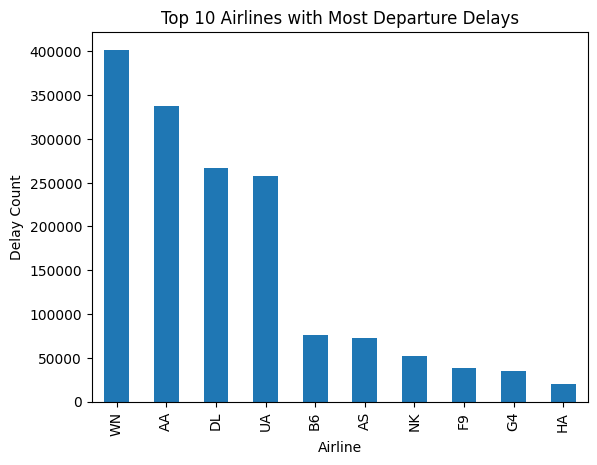

In [208]:
# Bar chart for Query 1
result1_df.plot(kind='bar', x='Airline', y='DelayCount', legend=False)
plt.title("Top 10 Airlines with Most Departure Delays")
plt.ylabel("Delay Count")
plt.xlabel("Airline")
plt.show()

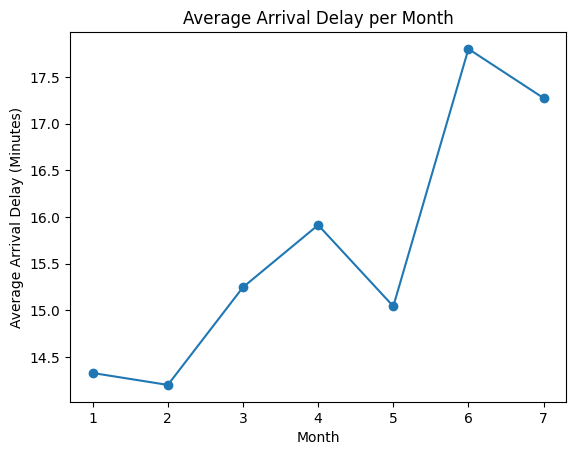

In [209]:
# Line plot for Query 2
plt.plot(result2_df['Month'], result2_df['AvgArrivalDelay'], marker='o')
plt.title("Average Arrival Delay per Month")
plt.ylabel("Average Arrival Delay (Minutes)")
plt.xlabel("Month")
plt.show()

In [210]:
 print(result3_df.columns)

Index(['Airline', 'AvgTaxiOutTime'], dtype='object')


In [211]:
result3.show()

+-------+------------------+
|Airline|    AvgTaxiOutTime|
+-------+------------------+
|     UA|19.168617045750832|
|     B6| 19.03581466798146|
|     AA|18.622459005806995|
|     F9|17.718593084410177|
|     DL|17.153833427526678|
|     AS|17.036657160411185|
|     NK|15.782641738866088|
|     G4|14.232860218709275|
|     WN|12.453035615685813|
|     HA|12.091399904443383|
+-------+------------------+



In [212]:
spark.sql("SELECT TaxiOut FROM flights WHERE TaxiOut IS NOT NULL LIMIT 5").show()

+-------+
|TaxiOut|
+-------+
|     17|
|     16|
|     21|
|     16|
|     19|
+-------+



Index(['Airline', 'AvgTaxiOutTime'], dtype='object')


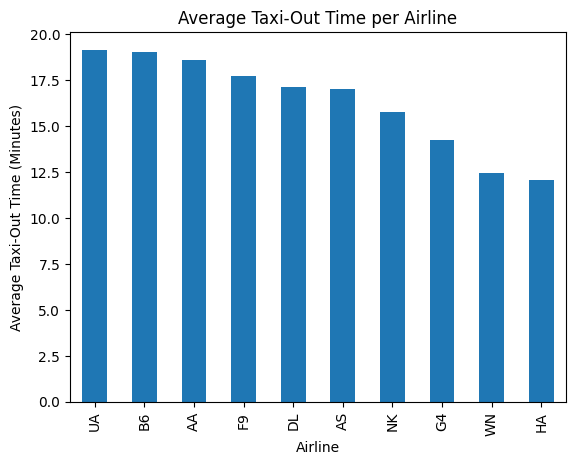

In [213]:
# Check columns in the DataFrame
print(result3_df.columns)

# Use the correct column name for plotting
result3_df.plot(kind='bar', x='Airline', y='AvgTaxiOutTime', legend=False)  # Adjust y='avgtaxiouttime' if needed
plt.title("Average Taxi-Out Time per Airline")
plt.ylabel("Average Taxi-Out Time (Minutes)")
plt.xlabel("Airline")
plt.show()

In [214]:
from pyspark.sql.functions import when
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [215]:
# Create a binary target column for cancellation or delay
# Target: 1 if canceled or delayed (DepDelayMinutes > 15), 0 otherwise
df = df.withColumn("Target", when((df["Cancelled"] == True) | (df["DepDelayMinutes"] > 15), 1).otherwise(0))

In [216]:
#Load Airlines Dataset
airlines_path = "/content/Airlines.csv"  # Replace with the actual file path
airlines_df = spark.read.csv(airlines_path, header=True, inferSchema=True)

In [217]:
# Drop rows with missing values for relevant features
df = df.dropna(subset=["TaxiOut", "Distance", "DepDelayMinutes", "DayOfWeek", "Marketing_Airline_Network"])

In [218]:
# Encode categorical variables (e.g., Airline)
indexer = StringIndexer(inputCol="Marketing_Airline_Network", outputCol="AirlineIndex")
df = indexer.fit(df).transform(df)

In [219]:
assembler = VectorAssembler(
    inputCols=["AirlineIndex", "TaxiOut", "Distance", "DayOfWeek"],
    outputCol="features"
)
df = assembler.transform(df).select("features", "Target", "Marketing_Airline_Network")


In [220]:
train_data, test_data = df.randomSplit([0.8, 0.2], seed=42)

In [221]:
# Initialize Logistic Regression
lr = LogisticRegression(labelCol="Target", featuresCol="features")

# Train the model
lr_model = lr.fit(train_data)

# Make predictions
lr_predictions = lr_model.transform(test_data)

# Evaluate Logistic Regression Model
evaluator = MulticlassClassificationEvaluator(labelCol="Target", metricName="accuracy")
lr_accuracy = evaluator.evaluate(lr_predictions)
print(f"Logistic Regression Accuracy: {lr_accuracy}")

Logistic Regression Accuracy: 0.7891485691269864


In [222]:
 # Initialize Random Forest Classifier
rf = RandomForestClassifier(labelCol="Target", featuresCol="features", numTrees=50)

# Train the model
rf_model = rf.fit(train_data)

# Make predictions
rf_predictions = rf_model.transform(test_data)

# Evaluate Random Forest Model
rf_accuracy = evaluator.evaluate(rf_predictions)
print(f"Random Forest Accuracy: {rf_accuracy}")

Random Forest Accuracy: 0.789135903171302


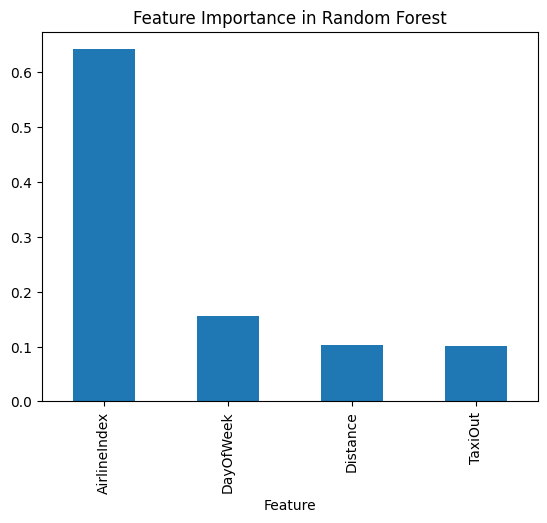

In [223]:
# Visualize Feature Importance for Random Forest
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importance for Random Forest
feature_importance = rf_model.featureImportances.toArray()
feature_names = ["AirlineIndex", "TaxiOut", "Distance", "DayOfWeek"]

# Create a DataFrame for visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df.sort_values("Importance", ascending=False).plot(kind="bar", x="Feature", y="Importance", legend=False)
plt.title("Feature Importance in Random Forest")
plt.show()

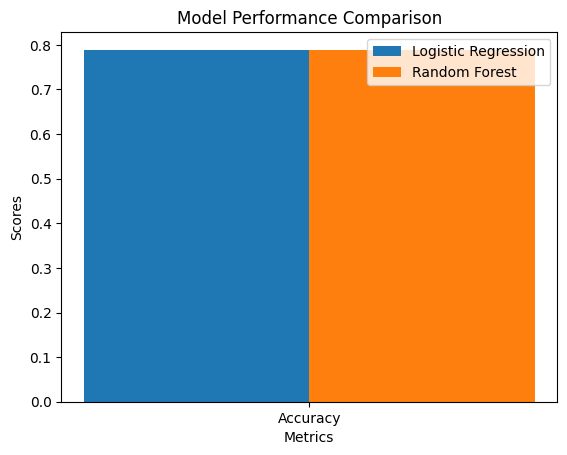

In [228]:
# Ensure lr_metrics and rf_metrics contain numeric values
metrics = ["Accuracy"]
lr_metrics = [lr_accuracy]
rf_metrics = [rf_accuracy]

x = range(len(metrics))

# Plot bar chart
plt.bar(x, lr_metrics, width=0.4, label='Logistic Regression', align='center')
plt.bar([p + 0.4 for p in x], rf_metrics, width=0.4, label='Random Forest', align='center')

plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.title('Model Performance Comparison')
plt.xticks([p + 0.2 for p in x], metrics)
plt.legend()
plt.show()